# Lab Assignment: Generative AI

#### Lab team: 09

##### Name (member 1): Yijun Wang

##### Name (member 2): Geer Wang Liu

* Please include your full name at the beginning of all submitted files.
* Make sure the presentation is well-structured: the report will be evaluated not only for correctness, but also for clarity, conciseness, and completeness.
* Make use of figures and tables to summarize the results and illustrate the discussions.
* If external material is used, the sources must be cited.
* Include references in APA format https://pitt.libguides.com/citationhelp/apa7. Lack or poorly formatted references can be penalized.
* A generative AI tool can be used for consultation. You must specify the tool used in your report.
* You are not allowed to use a generative AI tool to generate code.

Submit a single `.zip` file, whose name has the format `AA3_2024_2025_P02_teamCode_lastName1_lastName2.zip`
The name must not include graphical accents, spaces, uppercase letters, or special characters.

For example: `AA3_2024_2025_P02_V03_munyoz_deLaRosa.zip`

This compressed file must include the following files:

* This Python notebook with the solutions of the exercises. The notebook should include only code snippets, figures, tables, derviations and explanations (with LaTex if necessary) in Markdown cells. Handwritten material can be included in the Python notebook as images. Functions should be defined in a separate `.py` file, not in the notebook.
* The necessary `.py` and addional files to ensure the Python notebook code can be executed sequentially without errors.
* A PDF file generated from the notebook (Export the notebook as an HTML file. Open the HTML file in a Browser and print it as a PDF file).

Make sure that all the code cells can be executed squentially without errors (Kernel -> Restart & Run All). Exectution and formatting errors will be penalized.

The grade of this lab assignment is based on
* This submission (50 %).
* An individual in-class exam (50%).


Evaluation criteria:
* [6 points] Quality of the report (correctness, clarity, conciseness, completeness).
* [3 points] Quality of the code (correctness, adherence to a Python style guide -for instance, Google's-, comments, functional decomposition).
* [1 point]  References.                                                                   

## References:

1. Yang Song, Jascha Sohl-Dickstein, Diederik P. Kingma, Abhishek Kumar, Stefano Ermon and Ben Poole
"Score-Based Generative Modeling through Stochastic Differential Equations"
In International Conference on Learning Representations, 2021
https://arxiv.org/abs/2011.13456

2. TODO: Include references in alphabetical order

## Exercise 1:  Generative AI based on diffusion models: Brownian motion

In this exercise the training data is generated by injectiong noise using Brownian motion (variance exploding diffusion model).
The stochastic differencial equation (SDE) that characterizes this forward diffusion process is
$$
d\mathbf{x}(t) = \sigma^t d\mathbf{W}(t)
$$

with $ \mathbf{x}(0) \sim p_0\left(\mathbf{x} \right)$, and  $\sigma > 0 $.
1. What is the distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0) = \mathbf{x}_0$ for arbitrary t?
2. What is the SDE for the time-reversed process?
3. For the synthesis of new images
    1. In what interval is the reverse process SDE integrated?
    2. From which distribution $\pi\left(\mathbf{x} \right)$ is the initial condition of the reverse SDE sampled?

### **APARTADO 1**

El proceso *forward* viene dado por la SDE

$$
d\mathbf{x}(t) = g(t)\, d\mathbf{W}(t),
\qquad
\mathbf{x}(0)=\mathbf{x}_0,
$$

donde, en este ejercicio, se toma

$$
g(t)=\sigma^t, \qquad \sigma>0.
$$

Como no hay término de deriva, la solución del proceso es gaussiana con media igual al valor inicial. En consecuencia,

$$
\mathbf{x}(t)=\mathbf{x}_0+\sigma_t\,\mathbf{z},
\qquad
\mathbf{z}\sim\mathcal{N}(0,I),
$$

donde $\sigma_t^2$ es la varianza acumulada hasta el instante $t$. Por tanto,

$$
\mathbf{x}(t)\mid \mathbf{x}(0)=\mathbf{x}_0
\sim
\mathcal{N}\!\left(\mathbf{x}_0,\sigma_t^2 I\right).
$$

La varianza viene dada por

$$
\sigma_t^2=\int_0^t g^2(s)\,ds
=\int_0^t \sigma^{2s}\,ds
=
\frac{1}{2\log\sigma}\left(\sigma^{2t}-1\right).
$$

En consecuencia,

$$
\mathbf{x}(t)\mid \mathbf{x}(0)=\mathbf{x}_0
\sim
\mathcal{N}\!\left(
\mathbf{x}_0,
\frac{1}{2\log\sigma}\left(\sigma^{2t}-1\right)I
\right).
$$



### **APARTADO 2**

La SDE del proceso inverso asociada al modelo de difusión es

$$
d\tilde{\mathbf{x}}(t)
=
-\,g^2(t)\,\nabla_{\mathbf{x}}\log p_t(\tilde{\mathbf{x}}(t))\,dt
+
g(t)\,d\mathbf{W}(t),
\qquad
\tilde{\mathbf{x}}(0)\sim p_0(\mathbf{x}).
$$

En este caso, el proceso *forward* no tiene término de deriva, por lo que el término de deriva del proceso inverso queda únicamente determinado por el *score* de la distribución intermedia \(p_t\).

#### **Coeficientes**

- **Término de deriva**

$$
-\,g^2(t)\,\nabla_{\mathbf{x}}\log p_t(\tilde{\mathbf{x}}(t))
$$

- **Término de difusión**

$$
g(t)
$$

Como en la práctica el *score* exacto $\nabla_{\mathbf{x}}\log p_t(\mathbf{x})$ es desconocido, se aproxima mediante un modelo entrenado:

$$
s(\mathbf{x},t;\theta^*) \approx \nabla_{\mathbf{x}}\log p_t(\mathbf{x}).
$$

De este modo, la SDE inversa puede aproximarse por

$$
d\tilde{\mathbf{x}}(t)
\approx
-\,g^2(t)\,s(\tilde{\mathbf{x}}(t),t;\theta^*)\,dt
+
g(t)\,d\mathbf{W}(t).
$$



### **APARTADO 3.1**

Para sintetizar nuevas imágenes, la SDE inversa se integra en el intervalo

$$
[T,0],
$$

es decir, desde el tiempo final hasta el tiempo inicial, ya que el objetivo es revertir el proceso de difusión y recuperar una muestra de la distribución de datos original \(p_0(\mathbf{x})\).



### **APARTADO 3.2**

La condición inicial del proceso inverso se muestrea de una distribución de referencia $\pi(\mathbf{x})$, que en este caso se aproxima mediante la distribución del proceso *forward* en el instante final $T$:

$$
\pi(\mathbf{x}) \approx p_T(\mathbf{x})
=
\mathcal{N}(0,\sigma_T^2 I),
$$

donde

$$
\sigma_T^2
=
\frac{1}{2\log\sigma}\left(\sigma^{2T}-1\right).
$$

Por tanto, el proceso inverso comienza a partir de una normal multivariada de media cero y covarianza isotrópica.

### Exercise 1.1:  Training the model by weighted sum of denoising score matching objectives
1. Give the mathematical form and explain the cost function used in the training of the generative AI model.
2. Indicate what type of neural network is used to model the score, its inputs, outputs, and architecture.   
3. Explain how time is input in the neural network model for the time-dependent score function using random Fourier features.
4. Illustrate how to train a model to generate handwritten digits for the MNIST dataset using the Brownian motion diffusion model.
This first block of code should run in less than 5 minutes.

#### 1. Give the mathematical form and explain the cost function used in the training of the generative AI model.

**Condición Inicial**

El proceso comienza con la siguiente condición inicial, donde x0 es una muestra de la distribución de datos p0​, y pertenece al espacio RD:  

$$  
\mathbf{x}_0 = \mathbf{x}_0 \in \mathbb{R}^D  
$$  

**Proceso hacia adelante (Proceso de Difusión):**

El proceso hacia adelante describe la evolución de los datos a lo largo del tiempo, en la cual los datos se contaminan gradualmente con ruido. En cada instante t, los datos xt​ se transforman en función de una media μt​, una varianza σt​ y un término de ruido Z extraído de una distribución normal estándar:

$$  
\mathbf{x}_t \mid \mathbf{x}_0 = \mu_t + \sigma_t \mathbf{Z} \sim \mathcal{N}(\mu_t, \sigma_t^2 \mathbf{I})  
$$  

Cuando t -> inf, la distribución de xt​ converge a una distribución normal con media cero y varianza creciente:

$$  
\mathbf{x}_t \sim \mathcal{N}(0, \sigma_t^2 \mathbf{I})  
$$  

**Función de Pérdida Empírica (Score Matching Loss):**

La función de pérdida utilizada para entrenar el modelo es la pérdida de coincidencia de scores. El objetivo es encontrar la función de score (el gradiente del logaritmo de la verosimilitud) de la distribución de datos en cada instante de tiempo. La función de pérdida se define como el valor esperado del cuadrado de la diferencia entre el score predicho y el score verdadero, más el ruido:

$$  
\mathcal{L}_{\theta} = \mathbb{E}_{t \sim U[0,1]} \mathbb{E}_{\mathbf{x}_0 \sim p_0(\mathbf{x})}  
\mathbb{E}_{\mathbf{x} \sim p(\mathbf{x},t \mid \mathbf{x}_0,0)}  
\left[ \lambda_t \frac{1}{\sigma_t^2} \left\| \sigma_t s_{\theta}(\mathbf{x},t) + \mathbf{Z} \right\|^2 \right]  
$$  

Donde:

- Et∼U[0,1]​ denota la expectativa sobre los tiempos t muestreados uniformemente de [0,1].

- p0(x) es la distribución de los datos reales.

- p(x,t∣x0,0) es la distribución de los datos perturbados en el tiempo tt dado el dato inicial x0​.

- sθ(x,t) es la función de score (el gradiente del logaritmo de la probabilidad de x en el tiempo t).

- Z es el término de ruido gaussiano, donde Z∼N(0,I).

**Aproximación mediante muestreo:**

Como no podemos calcular las expectativas de manera exacta, aproximamos la función de pérdida mediante un promedio de muestras NN. Esto da como resultado la siguiente aproximación para la función de pérdida:

$$  
\mathcal{L}_{\theta} \approx \frac{1}{N} \sum_{n=1}^{N}  
\left\| \sigma_{t_n} s_{\theta}(\mathbf{x}_n, t_n) + \mathbf{Z}_n \right\|^2  
$$  

**Estimación de la Muestra:**

Las muestras utilizadas para calcular la función de pérdida se generan de la siguiente manera:  

- Muestreo del tiempo:  
Cada tiempo tn​ es extraído de una distribución uniforme sobre el intervalo [0,T]:
  $$  
  t_n \sim U[0,T]  
  $$  
- Generación de ruido gaussiano:  
El término de ruido Zn​ se extrae de una distribución normal estándar
  $$  
  \mathbf{Z}_n \sim \mathcal{N}(0,\mathbf{I})  
  $$  
- Cálculo de la perturbación en el tiempo \( t_n \):  
Utilizando el ruido Zn​, calculamos los datos perturbados en el tiempo tn​ como
  $$  
  \mathbf{x}_n(t_n) = \mu_{t_n} + \sigma_{t_n} \mathbf{Z}_n  
  $$  


#### 2. Indicate what type of neural network is used to model the score, its inputs, outputs, and architecture.  

La red neuronal utilizada para modelar la función de score en esta implementación es una **U-Net dependiente del tiempo** con varios componentes clave:

**Tipo de Red y Arquitectura**

**U-Net con embeddings de tiempo**:

- **Estructura encoder-decoder** con conexiones de salto (skip connections) entre bloques de resolución correspondientes.

- **Cuatro capas de codificación** que utilizan Conv2d con stride 2 para reducir la resolución (downsampling).

- **Tres capas de decodificación** que utilizan ConvTranspose2d con stride 2 para aumentar la resolución (upsampling).

- **Normalización por grupos** después de cada convolución.

- **Características Fourier aleatorias gaussianas** para codificar los pasos de tiempo.


Entradas

- x: Tensor de entrada con forma (batch_size, 1, height, width) (imágenes en escala de grises).

- t: Tensor que representa los pasos de tiempo con forma (batch_size,).

Salida

- Valores del score: Tensor con la misma forma que la entrada x, que representa la estimación de la función score ∇ₓlog pₜ(x).



#### 3. Explain how time is input in the neural network model for the time-dependent score function using random Fourier features.

El modelo de red neuronal introduce el tiempo t en la función de
puntaje dependiente del tiempo mediante random Fourier features (RFF).

Este enfoque transforma el tiempo en una representación de mayor dimensión
usando funciones sinusoidales, capturando la dependencia temporal de forma
efectiva en la red.

El módulo GaussianRandomFourierFeatures implementa una transformación no
lineal del tiempo mediante una proyección a un espacio de características
de mayor dimension.
$$
\phi(t) = \left[ \sin(2\pi W t), \cos(2\pi W t) \right]
$$
donde WW e una matriz de pesos aleatorios muestreados de una distribución Gaussiana y escalados por un factor de normalización.


**Incorporación de la representación temporal en la red neuronal**

La red ScoreNet emplea una arquitectura U-Net modificada en la que la información temporal se introduce en diferentes niveles mediante capas densas (Dense). Para ello, la salida de GaussianRandomFourierFeatures se transforma con una capa lineal.

Luego, la representación embebida del tiempo se inyecta en múltiples capas convolucionales a través de sumas directas con los mapas de características.

De esta manera, la información del tiempo modula la activación de cada capa, permitiendo que el modelo ajuste la función de puntaje en función del instante temporal t.

**Normalización de la salida con la desviación estándar marginal**

Finalmente, la salida de la red se normaliza mediante la desviación estándar marginal σ(t), que regula la escala de la función de puntaje en diferentes momentos



El tiempo se introduce en la red mediante random Fourier features, que transforman t en un espacio de características de mayor dimensión utilizando funciones sinusoidales. Esta representación se inyecta en la arquitectura U-Net mediante capas densas, asegurando que la información temporal influya en cada etapa del procesamiento. La normalización final garantiza que la salida del modelo sea consistente a lo largo del tiempo.

#### 4. Illustrate how to train a model to generate handwritten digits for the MNIST dataset using the Brownian motion diffusion model. This first block of code should run in less than 5 minutes.


In [1]:
# Importamos las funciones necesarias
from diffusion_model import load_mnist_data, create_diffusion_process, train_model, generate_images
import torch
import matplotlib.pyplot as lt
from diffusion_utilities import plot_image_grid, plot_image_evolution

##### 4.1. Cargar y Preprocesar el Dataset MNIST


In [2]:
# Cargar los datos de MNIST con el dígito 3
digit = 3
batch_size = 32

# Llamamos a la función 'load_mnist_data' que carga el dataset MNIST, filtra las imágenes del dígito seleccionado
data_loader, data_train = load_mnist_data(digit=digit, batch_size=batch_size)

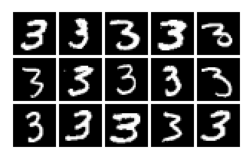

In [3]:
# Visualizamos algunas de las imágenes cargadas
n_rows = 3
n_cols = 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize=(3, 3),
    n_rows=n_rows,
    n_cols=n_cols,
)

##### 4.2 Crear el Proceso de Difución

In [4]:
# Definir el proceso de difusión
sigma = 25.0
diffusion_process, diffusion_coefficient, sigma_t = create_diffusion_process(sigma=sigma)

##### 4.3 Definir y Entrenar el Modelo de Score

In [5]:
# Definir el modelo de score
from score_model import ScoreNet

# Definir el modelo de score utilizando ScoreNet
score_model = torch.nn.DataParallel(
    ScoreNet(marginal_prob_std=sigma_t)
).to('cpu')

# Entrenar el modelo
n_epochs = 15 # Definir el número de épocas de entrenamiento
train_model(data_loader, diffusion_process, score_model, n_epochs=n_epochs,
            learning_rate=1e-3, device='cpu') # Llamar a la función de entrenamiento para entrenar el modelo

  0%|          | 0/15 [00:00<?, ?it/s]

##### 4.4 Generar Imágenes con el Modelo Entrenado

Una vez que el modelo ha sido entrenado, generamos nuevas imágenes utilizando el modelo de difusión invertido, comenzando con ruido blanco y siguiendo el proceso inverso para crear imágenes similares a los dígitos manuscritos.

In [6]:
# Cargar el modelo entrenado
score_model.load_state_dict(torch.load('check_point.pth', map_location='cpu'))

# Generar imágenes con el modelo entrenado
synthetic_images_t = generate_images(score_model, diffusion_process, n_images=3, device='cpu')


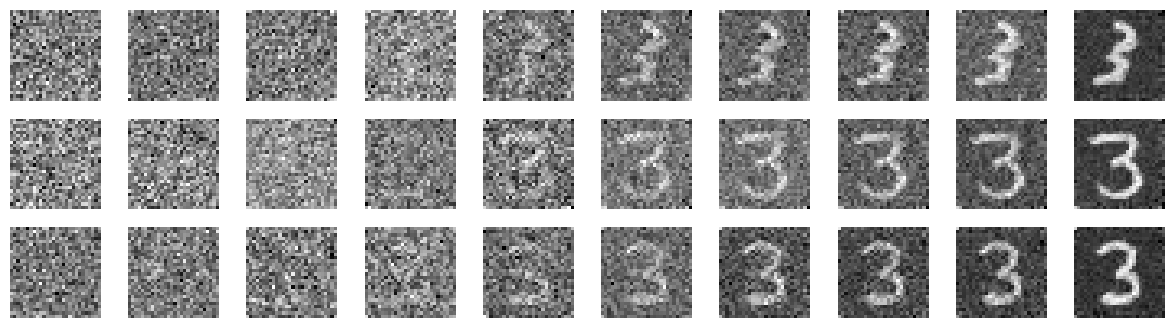

In [7]:
# Visualizar la evolución de las imágenes generadas
_ = plot_image_evolution(
    images=synthetic_images_t,
    n_images=3,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

### Exercise 1.2: Generation using the Euler-Maruyama integrator
Use a model that you have previously trained (not the one in the previous exercise) high-quality model to generate some samples using the Euler-Maruyama integrator.

Se ha entrenado un modelo nuevo con el dataset MNIST usando el proceso de difusión basado en movimiento browniano.

En esta versión, el modelo se entrena en todas las imágenes del MNIST (dígitos 0-9).

Se ha aumentado el número de épocas a 150 para mejorar la calidad de las imágenes generadas.

El modelo entrenado se guarda en 'check_point_150.pth'.

In [8]:
# Definir el número de imágenes a generar
n_images = 4

# Cargar el modelo entrenado desde el checkpoint guardado
check_point_150 = torch.load('check_point_150.pth', map_location='cpu')  # Se asegura que cargue en la CPU
score_model.load_state_dict(check_point_150)  # Cargar los pesos entrenados en el modelo

# Generar imágenes con el modelo entrenado usando el proceso de difusión
synthetic_images_t = generate_images(score_model, diffusion_process, n_images=n_images, device='cpu')

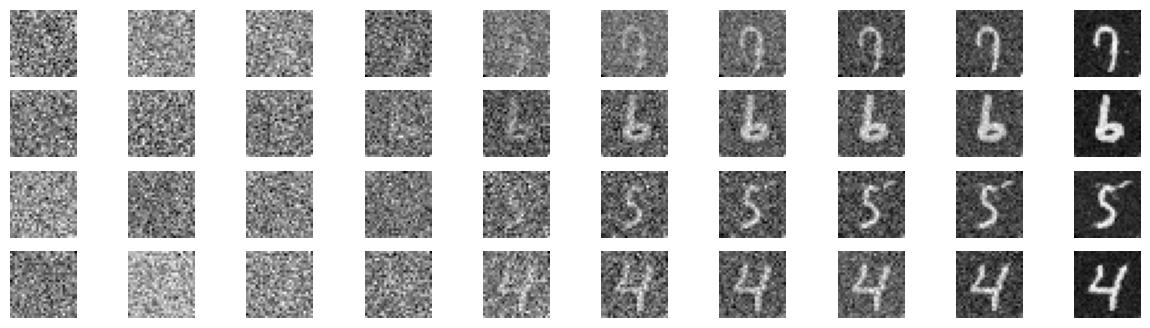

In [9]:
# Visualizar la evolución de las imágenes generadas
_ = plot_image_evolution(
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

### Exercise 1.3: Generation using a probability flow ODE.
1. Explain what is the Fokker-Planck equation and in what way is it related to an SDE.


Consideremos una ecuación diferencial estocástica (SDE) en forma de Itô:

$$
d\mathbf{x} = \mathbf{f}(\mathbf{x},t)\,dt + g(t)\,d\mathbf{w}
$$

donde $\mathbf{f}(\mathbf{x},t)$ es el término de deriva (drift), $g(t)$ es el coeficiente de difusión y $\mathbf{w}$ es un proceso de Wiener estándar.

La ecuación de Fokker-Planck describe la evolución temporal de la densidad de probabilidad $p_t(\mathbf{x})$ asociada a esta SDE:

$$
\frac{\partial p_t(\mathbf{x})}{\partial t}
=
-\nabla_{\mathbf{x}} \cdot \left( \mathbf{f}(\mathbf{x},t)p_t(\mathbf{x}) \right)
+
\frac{1}{2} g(t)^2 \Delta_{\mathbf{x}} p_t(\mathbf{x})
$$

Esta ecuación indica cómo la probabilidad se transporta (por la deriva) y se difunde (por el ruido).

Una idea clave es que existe una ODE determinista equivalente que induce las mismas distribuciones marginales $p_t(\mathbf{x})$, llamada **probability flow ODE**:

$$
\frac{d\mathbf{x}}{dt}
=
\mathbf{f}(\mathbf{x},t)
-
\frac{1}{2}g(t)^2 \nabla_{\mathbf{x}} \log p_t(\mathbf{x})
$$

Por tanto, la relación es:

- La SDE describe trayectorias aleatorias.
- La ecuación de Fokker-Planck describe la evolución de la densidad.
- La probability flow ODE reproduce esa misma evolución de forma determinista.

2. Explain how the probability flow ODE can be used to generate samples from  $p_0\left(\mathbf{x} \right)$.

En modelos generativos basados en score (score-based models), se define una SDE directa que transforma datos reales en ruido:

$$
\mathbf{x}_0 \sim p_0(\mathbf{x})
\quad \longrightarrow \quad
\mathbf{x}_T \sim p_T(\mathbf{x}) \approx \mathcal{N}(0, I)
$$

Para generar nuevas muestras, se invierte este proceso comenzando desde ruido:

$$
\mathbf{x}_T \sim p_T(\mathbf{x})
$$

y resolviendo la ODE hacia atrás en el tiempo:

$$
\frac{d\mathbf{x}}{dt}
=
\mathbf{f}(\mathbf{x},t)
-
\frac{1}{2}g(t)^2 s_\theta(\mathbf{x},t)
$$

donde

$$
s_\theta(\mathbf{x},t) \approx \nabla_{\mathbf{x}} \log p_t(\mathbf{x})
$$

es una red neuronal entrenada para aproximar el score.

Así, al integrar desde $t=T$ hasta $t=0$, obtenemos:

$$
\mathbf{x}_T \rightarrow \mathbf{x}_0
$$

lo que transforma ruido gaussiano en muestras realistas, como imágenes de dígitos manuscritos.

2. Implement and illustrate the use of this method to generate synthetic images of handwritten digits.

La probability flow ODE permite generar muestras resolviendo de forma determinista:

$$
\frac{d\mathbf{x}}{dt}
=
\mathbf{f}(\mathbf{x},t)
-
\frac{1}{2}g(t)^2s_\theta(\mathbf{x},t)
$$

donde $s_\theta(\mathbf{x},t)$ es el modelo score entrenado.

Para generar imágenes, partimos de ruido en $t=T$:

$$
\mathbf{x}_T \sim p_T(\mathbf{x})
$$

y resolvemos la ODE hacia atrás hasta $t \approx 0$:

$$
\mathbf{x}_T \rightarrow \mathbf{x}_0
$$

De esta forma, el ruido inicial se transforma progresivamente en imágenes similares a las de MNIST.

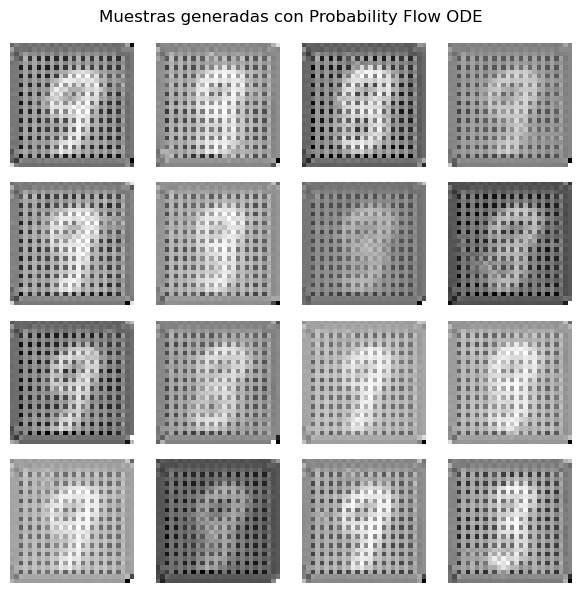

In [24]:
import torch
import matplotlib.pyplot as plt

# Generación con el sampler ODE del proyecto
score_model.eval()

times, synthetic_images_t = ode_sampler(
    score_model=score_model,
    diffusion_process=diffusion_process,
    scheme="ve",
    beta_t=None,
    n_steps=500,
    n_images=16,
    T=1.0,
    eps=1e-3,
    device=device
)

# Imagen final: último paso de la trayectoria
samples_final = synthetic_images_t[..., -1].detach().cpu()

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(samples_final[i, 0], cmap="gray")
    ax.axis("off")

plt.suptitle("Muestras generadas con Probability Flow ODE")
plt.tight_layout()
plt.show()



3. Indicate how to use this scheme to compute likelihoods. Implement this functionality and illustrate its use.

La probability flow ODE también permite calcular likelihoods mediante el cambio de variables continuo.

Para una ODE:

$$
\frac{d\mathbf{x}}{dt}
=
\mathbf{v}_\theta(\mathbf{x},t)
$$

la densidad cambia según:

$$
\frac{d \log p_t(\mathbf{x})}{dt}
=
-\nabla_{\mathbf{x}} \cdot \mathbf{v}_\theta(\mathbf{x},t)
$$

En nuestro caso:

$$
\mathbf{v}_\theta(\mathbf{x},t)
=
\mathbf{f}(\mathbf{x},t)
-
\frac{1}{2}g(t)^2s_\theta(\mathbf{x},t)
$$

Por tanto, para calcular $\log p_0(\mathbf{x}_0)$, integramos desde los datos hasta el ruido:

$$
\log p_0(\mathbf{x}_0)
=
\log p_T(\mathbf{x}_T)
+
\int_0^T
\nabla_{\mathbf{x}} \cdot \mathbf{v}_\theta(\mathbf{x}_t,t)
\,dt
$$

Como calcular la divergencia exacta es costoso, usamos el estimador de Hutchinson:

$$
\nabla_{\mathbf{x}} \cdot \mathbf{v}_\theta(\mathbf{x},t)
\approx
\epsilon^T
\frac{\partial \mathbf{v}_\theta}{\partial \mathbf{x}}
\epsilon
$$

## Exercise 2: Generative AI based on diffusion models: The Ornstein–Uhlenbeck process

In this exercise, the training data is generated by injecting noise using Brownian motion (variance preserving diffusion model).  
The stochastic differential equation (SDE) that characterizes this forward diffusion process is:

$$
d\mathbf{x}(t) = - \frac{1}{2} \beta(t) \mathbf{x}(t)\,dt + \sqrt{\beta(t)}\, d\mathbf{W}(t)
$$

with:

$$
\mathbf{x}(0) \sim p_0(\mathbf{x})
$$



### 1. Distribution of $\mathbf{x}(t)$ assuming that $\mathbf{x}(0)=\mathbf{x}_0$

Definimos:

$$
B(t)=\int_0^t \beta(s)\,ds
$$

La distribución de $\mathbf{x}(t)$ es gaussiana:

$$
\mathbf{x}(t)\mid \mathbf{x}(0)=\mathbf{x}_0
\sim
\mathcal{N}
\left(
e^{-\frac{1}{2}B(t)}\mathbf{x}_0,\;
\left(1-e^{-B(t)}\right)I
\right)
$$

Equivalentemente:

$$
\mathbf{x}(t)
=
e^{-\frac{1}{2}B(t)}\mathbf{x}_0
+
\sqrt{1-e^{-B(t)}}\,\mathbf{z},
\quad
\mathbf{z}\sim\mathcal{N}(0,I)
$$



### 2. SDE for the time-reversed process

Para una SDE general:

$$
d\mathbf{x}
=
\mathbf{f}(\mathbf{x},t)\,dt
+
g(t)\,d\mathbf{W}(t)
$$

la SDE inversa es:

$$
d\mathbf{x}
=
\left[
\mathbf{f}(\mathbf{x},t)
-
g(t)^2\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
\right]dt
+
g(t)\,d\bar{\mathbf{W}}(t)
$$

En nuestro caso:

$$
\mathbf{f}(\mathbf{x},t) = -\frac{1}{2}\beta(t)\mathbf{x},
\qquad
g(t)=\sqrt{\beta(t)}
$$

Sustituyendo:

$$
d\mathbf{x}(t)
=
\left[
-\frac{1}{2}\beta(t)\mathbf{x}(t)
-
\beta(t)\nabla_{\mathbf{x}}\log p_t(\mathbf{x}(t))
\right]dt
+
\sqrt{\beta(t)}\,d\bar{\mathbf{W}}(t)
$$

En la práctica, el score se aproxima con una red neuronal:

$$
s_\theta(\mathbf{x},t)
\approx
\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
$$

y queda:

$$
d\mathbf{x}(t)
=
\left[
-\frac{1}{2}\beta(t)\mathbf{x}(t)
-
\beta(t)s_\theta(\mathbf{x}(t),t)
\right]dt
+
\sqrt{\beta(t)}\,d\bar{\mathbf{W}}(t)
$$



### 3. For the synthesis of new images

#### 3.1 Intervalo de integración

El proceso inverso se integra hacia atrás en el tiempo:

$$
t=T \longrightarrow t=0
$$

En la práctica, por estabilidad numérica:

$$
t=T-\varepsilon \longrightarrow t=\varepsilon
$$

donde $\varepsilon$ es pequeño.



#### 3.2 Distribución inicial $\pi(\mathbf{x})$

La condición inicial del proceso inverso se toma de la distribución en el tiempo final:

$$
\mathbf{x}_T \sim \pi(\mathbf{x})
$$

Para el modelo VP:

$$
\pi(\mathbf{x}) \approx \mathcal{N}(0,I)
$$

Por tanto, la generación comienza desde ruido gaussiano:

$$
\mathbf{x}_T \sim \mathcal{N}(0,I)
\quad \longrightarrow \quad
\mathbf{x}_0 \sim p_0(\mathbf{x})
$$

### Exercise 2.1: Training and generation of images using the OU process and different noise schedules

En este apartado se entrena y se usa el modelo de difusión VP asociado al proceso de Ornstein–Uhlenbeck:

$$
d\mathbf{x}(t)
=
-\frac{1}{2}\beta(t)\mathbf{x}(t)\,dt
+
\sqrt{\beta(t)}\,d\mathbf{W}(t)
$$

La diferencia entre los experimentos está en la elección del schedule de ruido $\beta(t)$.

#### 1. Linear noise schedule

En el schedule lineal, $\beta(t)$ aumenta de forma lineal desde un valor mínimo hasta un valor máximo:

$$
\beta(t)
=
\beta_{\min}
+
(\beta_{\max}-\beta_{\min})\frac{t}{T}
$$

Su integral acumulada es:

$$
B(t)
=
\int_0^t \beta(s)\,ds
=
\beta_{\min}t
+
\frac{\beta_{\max}-\beta_{\min}}{2T}t^2
$$

Este schedule introduce poco ruido al principio y cada vez más ruido conforme avanza el tiempo.


#### 2. Cosine noise schedule

En el schedule cosine, el nivel de ruido se controla mediante una función coseno. Se define:

$$
\bar{\alpha}(t)
=
\frac{
\cos^2\left(
\frac{\pi}{2}
\frac{t/T+s}{1+s}
\right)
}{
\cos^2\left(
\frac{\pi}{2}
\frac{s}{1+s}
\right)
}
$$

A partir de ella:

$$
B(t)=-\log \bar{\alpha}(t)
$$

y

$$
\beta(t)
=
-\frac{d}{dt}\log \bar{\alpha}(t)
$$

Este schedule suele introducir el ruido de forma más suave, especialmente al principio del proceso.


#### 3. Third noise schedule

Como tercer schedule, se puede usar un schedule cuadrático:

$$
\beta(t)
=
\beta_{\min}
+
(\beta_{\max}-\beta_{\min})
\left(\frac{t}{T}\right)^2
$$

Su integral acumulada es:

$$
B(t)
=
\int_0^t \beta(s)\,ds
=
\beta_{\min}t
+
\frac{\beta_{\max}-\beta_{\min}}{3T^2}t^3
$$

Este schedule introduce el ruido más lentamente al principio y de forma más agresiva cerca de $T$.


En los tres casos, una vez entrenado el score model:

$$
s_\theta(\mathbf{x},t)
\approx
\nabla_{\mathbf{x}}\log p_t(\mathbf{x})
$$

las imágenes se generan resolviendo la SDE inversa desde ruido gaussiano:

$$
\mathbf{x}_T \sim \mathcal{N}(0,I)
$$

hasta obtener una muestra aproximada de la distribución de datos:

$$
\mathbf{x}_0 \sim p_0(\mathbf{x})
$$

## Exercise 3: Evaluation of the quality of the generated images

### 1. Medidas de calidad en modelos generativos

#### 1.1 Negative Log-Likelihood (NLL)

La *negative log-likelihood* (NLL) mide la probabilidad que el modelo asigna a los datos reales:

$$
\text{NLL} = - \mathbb{E}_{\mathbf{x} \sim p_0} [\log p_\theta(\mathbf{x})]
$$

En términos prácticos, cuanto menor es este valor, mejor está capturando el modelo la distribución de los datos.

Una de sus principales ventajas es que se trata de una medida bien fundamentada desde el punto de vista probabilístico, lo que permite comparar modelos de forma directa. Además, está relacionada con el principio de máxima verosimilitud, que es la base de muchos métodos de aprendizaje.

Sin embargo, tiene una limitación importante: un buen valor de NLL no garantiza que las imágenes generadas sean visualmente realistas. De hecho, algunos modelos con buen NLL tienden a producir imágenes borrosas. Además, en muchos modelos generativos su cálculo no es sencillo, aunque en diffusion models combinados con ODE sí se puede estimar.



#### 1.2 Bits Per Dimension (BPD)

El BPD es simplemente una versión normalizada del NLL:

$$
\text{BPD}
=
\frac{\text{NLL}}{D \cdot \log 2}
$$

donde $D$ representa el número de dimensiones (por ejemplo, el número de píxeles).

Se puede interpretar como el número de bits necesarios para codificar cada dimensión de los datos. Por tanto, valores más bajos indican un modelo más eficiente en términos de compresión, y en general, un mejor ajuste a la distribución real.

La principal ventaja del BPD es que permite comparar modelos de manera más justa entre distintos datasets o configuraciones. Además, su interpretación es bastante intuitiva.

Como desventaja, hereda los problemas del NLL: no siempre refleja bien la calidad visual de las imágenes y puede favorecer soluciones demasiado suaves o poco detalladas.


#### 1.3 Fréchet Inception Distance (FID)

El FID mide la distancia entre la distribución de las imágenes reales y la de las generadas, pero no en el espacio de píxeles, sino en un espacio de características extraídas por una red preentrenada:

$$
\text{FID}
=
\|\mu_r - \mu_g\|^2
+
\text{Tr}(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2})
$$

donde $(\mu_r, \Sigma_r)$ corresponden a los datos reales y $(\mu_g, \Sigma_g)$ a los generados.

A diferencia del NLL, el FID sí correlaciona bastante bien con la calidad visual: detecta imágenes poco realistas, artefactos o falta de diversidad.

Entre sus ventajas destaca precisamente esto: es una métrica más alineada con la percepción humana. Sin embargo, depende de la red Inception utilizada y puede variar según el tamaño del conjunto de muestras. Además, no mide la verosimilitud real del modelo, sino solo similitud estadística.


#### 1.4 Medida adicional: Inception Score (IS)

El Inception Score evalúa simultáneamente la calidad y la diversidad de las imágenes generadas:

$$
\text{IS}
=
\exp\left(
\mathbb{E}_{\mathbf{x}}
\left[
D_{KL}(p(y|\mathbf{x}) \| p(y))
\right]
\right)
$$

La idea es que una buena imagen debería tener una predicción clara (baja entropía condicional) y, en conjunto, el modelo debería generar imágenes variadas (alta entropía marginal).

Es fácil de calcular y bastante intuitivo, pero tiene limitaciones importantes. No utiliza datos reales, por lo que no mide directamente el realismo, y puede dar valores altos incluso cuando las imágenes no son realmente buenas. Por ello, hoy en día se considera menos fiable que el FID.



### 2. Comparación usando BPD

El BPD es especialmente útil en diffusion models porque permite evaluar directamente la calidad probabilística del modelo.

#### Modelos de difusión

En el caso del proceso basado en **Brownian motion (VE)**, el ruido se añade sin un término de deriva que controle la evolución. Esto suele dificultar el ajuste fino a la distribución de los datos, dando lugar a valores de BPD más altos.

Por el contrario, el proceso de **Ornstein–Uhlenbeck (VP)** introduce un término de control que estabiliza la varianza. Esto facilita el aprendizaje y normalmente se traduce en un mejor ajuste, es decir, un BPD más bajo.



#### Noise schedules

El comportamiento del modelo también depende de cómo se introduce el ruido:

- Con un **schedule lineal**, el ruido aumenta de forma uniforme. Es sencillo, pero no siempre es el más eficiente.
- El **schedule cosine** introduce el ruido de manera más progresiva, especialmente al principio, lo que suele mejorar el entrenamiento y reducir el BPD.
- Otros schedules (por ejemplo, cuadráticos) permiten controlar mejor en qué fases del proceso se añade más ruido, aunque su rendimiento depende del caso concreto.



#### Sampling strategies

El método de muestreo también influye en los resultados:

- Los métodos basados en **SDE** (como Euler-Maruyama o Predictor-Corrector) son estocásticos. Esto suele aumentar la diversidad de las muestras, pero puede empeorar la verosimilitud, resultando en un BPD mayor.
- En cambio, los métodos basados en **ODE** (probability flow) son deterministas y permiten calcular likelihoods de forma más precisa, lo que generalmente conduce a mejores valores de BPD.



### Conclusión

El BPD es una buena medida para evaluar el ajuste probabilístico del modelo, mientras que métricas como FID reflejan mejor la calidad visual.

En general, se observa que:
- Los modelos **VP** suelen comportarse mejor que los VE.
- El **schedule cosine** mejora el rendimiento frente al lineal.
- El muestreo mediante **ODE** tiende a obtener mejores resultados en términos de BPD.

Sin embargo, un buen modelo en términos de BPD no siempre es el que genera las imágenes más realistas, por lo que es recomendable combinar varias métricas para una evaluación más completa.

## **References**

- Brownian motion. (2024, April 1). In *Wikipedia*. https://en.wikipedia.org/wiki/Brownian_motion

- Euler–Maruyama method. (2024, April 1). In *Wikipedia*. https://en.wikipedia.org/wiki/Euler%E2%80%93Maruyama_method

- PyTorch. (n.d.). *torch — PyTorch 2.0 documentation*. https://pytorch.org/docs/stable/library.html#module-torch.library

- Song, Y., Sohl-Dickstein, J., Kingma, D. P., Kumar, A., Ermon, S., & Poole, B. (2021). *Score-based generative modeling through stochastic differential equations*. In *International Conference on Learning Representations (ICLR 2021)*. https://arxiv.org/abs/2011.13456

- Suárez, A. (2025). *Diffusion models for generative AI* . Universidad Autónoma de Madrid.

- Suárez, A. (2025). *Generative AI for images* . Universidad Autónoma de Madrid.

- Generative AI Tool (ChatGPT, perplexity)(para la consulta sobre problemas y generación de texto)